# CSE422 Lab Project — Tree Sterility Dataset

## 2. Dataset Description

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    precision_score, recall_score, roc_auc_score
)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Tree_Sterility_Dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (2783, 24)


,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,...,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,...,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,...,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,...,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,...,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,...,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN


### 2.1 Dataset Overview

In [ ]:
print('Data types:')
print(df.dtypes)
print('\nTarget distribution:')
print(df['Sterile'].value_counts())

Data types:
No               int64
Plot             int64
Subplot         object
Species         object
Light_ISF      float64
Light_Cat       object
Core             int64
Soil            object
Adult           object
Sterile         object
Conspecific     object
Myco            object
SoilMyco        object
PlantDate       object
AMF            float64
EMF            float64
Phenolics      float64
Lignin         float64
NSC            float64
Census           int64
Time           float64
Event          float64
Harvest         object
Alive           object
dtype: object

Target distribution:
Sterile
Non-Sterile    2360
Sterile         423
Name: count, dtype: int64


### 2.2 Correlation Heatmap

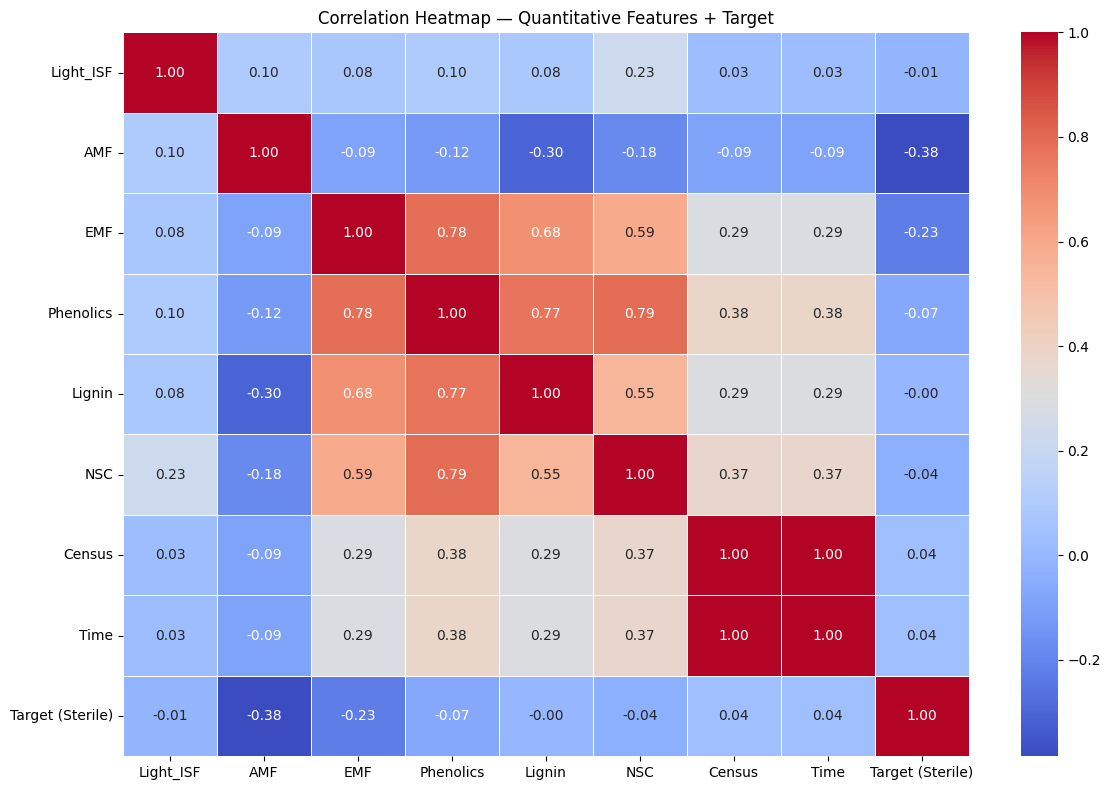

In [ ]:
num_cols = ['Light_ISF', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time']
df_num = df[num_cols].copy()
df_num['EMF'] = pd.to_numeric(df_num['EMF'], errors='coerce').fillna(0)
df_num['Target (Sterile)'] = (df['Sterile'] == 'Sterile').astype(int)

plt.figure(figsize=(12, 8))
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Quantitative Features + Target')
plt.tight_layout()
plt.show()                                                              # Key observations:
                                                                        # Census and Time are nearly perfectly correlated (r=0.99) — both track time elapsed.
                                                                        # AMF and EMF are negatively correlated: tree species associate with one type of fungus, not both.
                                                                        # EMF has the strongest correlation with the target (-0.55) — it is the most predictive numeric feature.
                                                                        # AMF also correlates with the target (-0.38).
                                                                        # Phenolics, Lignin, NSC, and Light_ISF have very weak individual correlation with the target.

### 2.3 Imbalanced Dataset Check

Class Distribution:
Sterile
Non-Sterile    2360
Sterile         423
Name: count, dtype: int64

Imbalance ratio: 5.6:1 (Non-Sterile to Sterile)


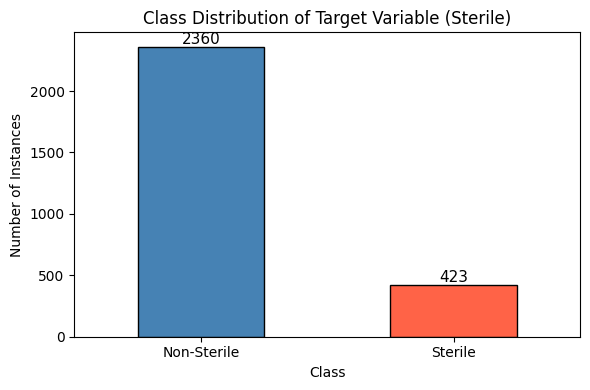


Dataset is imbalanced: Non-Sterile (2360) vs Sterile (423)
Stratified splitting will be used to preserve this proportion in train/test sets.


In [ ]:
class_counts = df['Sterile'].value_counts()
print('Class Distribution:')
print(class_counts)
print(f'\nImbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1 (Non-Sterile to Sterile)')

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Class Distribution of Target Variable (Sterile)')
plt.xlabel('Class')
plt.ylabel('Number of Instances')
plt.xticks(rotation=0)
for i, v in enumerate(class_counts):
    plt.text(i, v + 20, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print('\nDataset is imbalanced: Non-Sterile (2360) vs Sterile (423)')
print('Stratified splitting will be used to preserve this proportion in train/test sets.')

### 2.4 Exploratory Data Analysis (EDA)

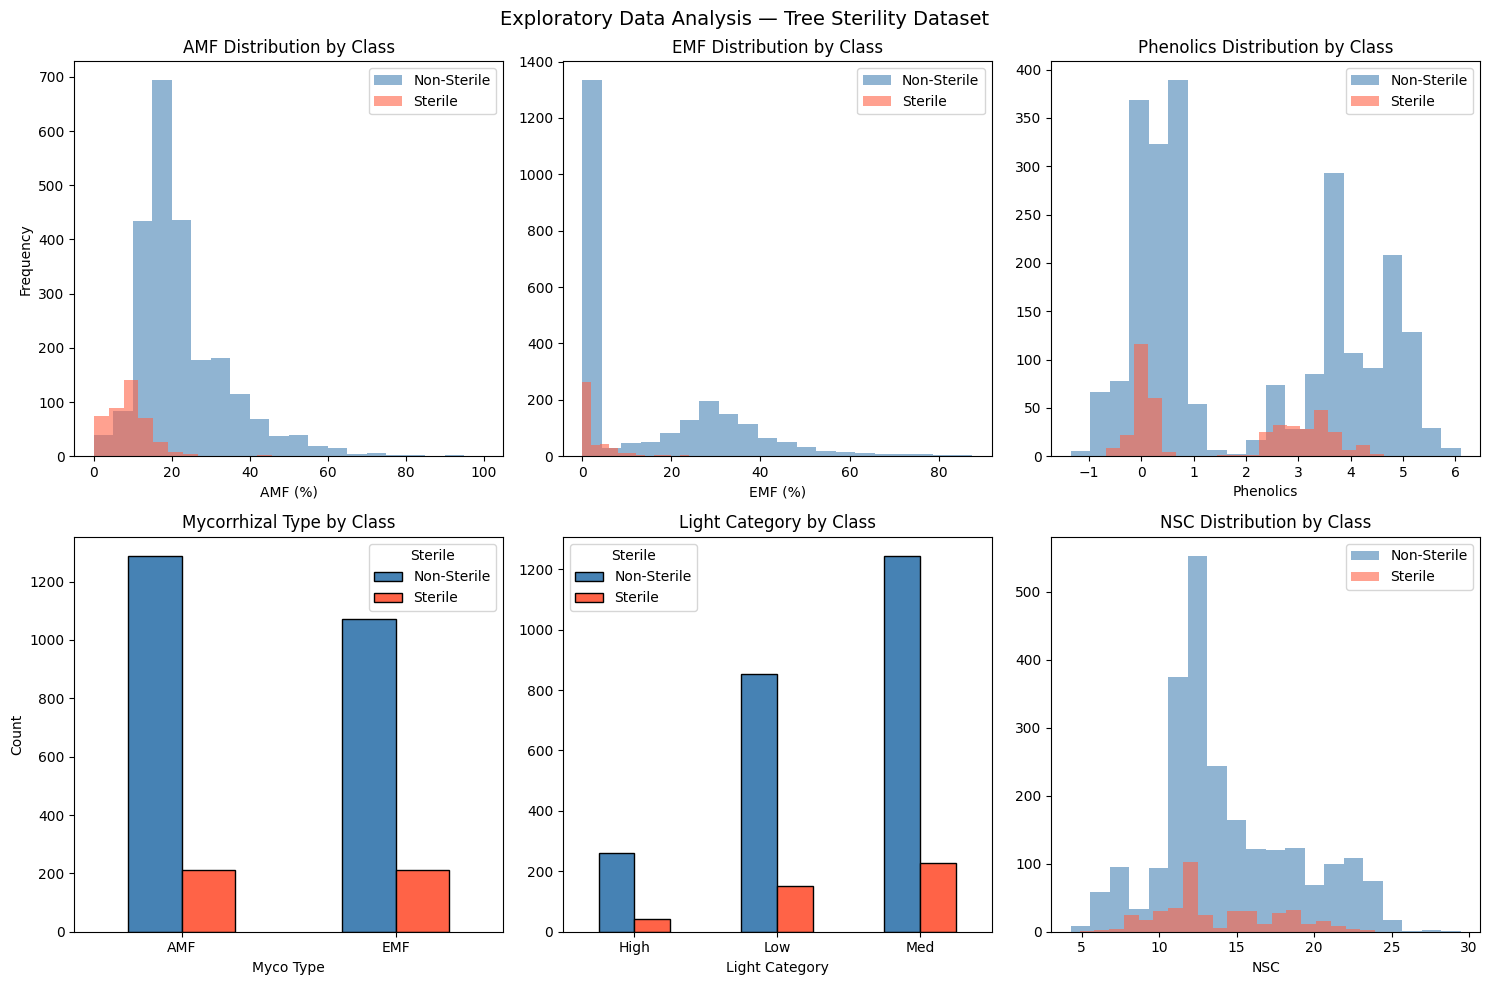

In [ ]:
df_eda = df.copy()
df_eda['EMF'] = pd.to_numeric(df_eda['EMF'], errors='coerce').fillna(0)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
for label, color in zip(['Non-Sterile', 'Sterile'], ['steelblue', 'tomato']):
    plt.hist(df_eda[df_eda['Sterile']==label]['AMF'], bins=20, alpha=0.6, label=label, color=color)
plt.title('AMF Distribution by Class')
plt.xlabel('AMF (%)')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 3, 2)
for label, color in zip(['Non-Sterile', 'Sterile'], ['steelblue', 'tomato']):
    plt.hist(df_eda[df_eda['Sterile']==label]['EMF'], bins=20, alpha=0.6, label=label, color=color)
plt.title('EMF Distribution by Class')
plt.xlabel('EMF (%)')
plt.legend()

plt.subplot(2, 3, 3)
for label, color in zip(['Non-Sterile', 'Sterile'], ['steelblue', 'tomato']):
    plt.hist(df_eda[df_eda['Sterile']==label]['Phenolics'], bins=20, alpha=0.6, label=label, color=color)
plt.title('Phenolics Distribution by Class')
plt.xlabel('Phenolics')
plt.legend()

plt.subplot(2, 3, 4)
pd.crosstab(df_eda['Myco'], df_eda['Sterile']).plot(kind='bar', ax=plt.gca(),
    color=['steelblue','tomato'], edgecolor='black')
plt.title('Mycorrhizal Type by Class')
plt.xlabel('Myco Type')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(2, 3, 5)
pd.crosstab(df_eda['Light_Cat'], df_eda['Sterile']).plot(kind='bar', ax=plt.gca(),
    color=['steelblue','tomato'], edgecolor='black')
plt.title('Light Category by Class')
plt.xlabel('Light Category')
plt.xticks(rotation=0)

plt.subplot(2, 3, 6)
for label, color in zip(['Non-Sterile', 'Sterile'], ['steelblue', 'tomato']):
    plt.hist(df_eda[df_eda['Sterile']==label]['NSC'], bins=20, alpha=0.6, label=label, color=color)
plt.title('NSC Distribution by Class')
plt.xlabel('NSC')
plt.legend()

plt.suptitle('Exploratory Data Analysis — Tree Sterility Dataset', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# print(pd.crosstab(df['SoilMyco'], df['Sterile']))
# print()
# print(pd.crosstab(df['Soil'], df['Sterile']))
# print()
# print(pd.crosstab(df['Conspecific'], df['Sterile']))


# for col in df.columns:
#     ct = pd.crosstab(df[col], df['Sterile'])
#     # Check if any cell is zero
#     if (ct == 0).any().any():
#         print(f"LEAKY: {col}")
#         print(ct)
#         print()
#     else:
#         print(f"SAFE:  {col}")
#         print(ct)
#         print()

LEAKY: No
Sterile  Non-Sterile  Sterile
No                           
3                  1        0
11                 1        0
12                 1        0
14                 1        0
18                 1        0
...              ...      ...
7765               1        0
7768               1        0
7769               1        0
7771               0        1
7772               1        0

[2783 rows x 2 columns]

SAFE:  Plot
Sterile  Non-Sterile  Sterile
Plot                         
1                135       23
2                121       24
3                133       24
4                126       24
5                128       24
6                132       24
7                135       24
8                119       24
9                123       24
10               137       23
11               144       23
12               135       24
13               121       22
14               132       23
15               135       24
16               127       24
17               133  

---
## 3. Dataset Pre-processing

In [ ]:
print('Missing values per column:')
print(df.isnull().sum())

leaky_cols = ['Soil', 'SoilMyco', 'Conspecific']
drop_cols  = ['No', 'Plot', 'PlantDate', 'Adult', 'Core', 'Harvest', 'Alive', 'Event']

df_clean = df.drop(columns=leaky_cols + drop_cols)

df_clean['EMF'] = pd.to_numeric(df_clean['EMF'], errors='coerce').fillna(0)
df_clean = df_clean.dropna()

print('\nShape after cleaning:', df_clean.shape)
print('Missing values remaining:', df_clean.isnull().sum().sum())
print('\nRemaining columns:', df_clean.columns.tolist())

Missing values per column:
No                0
Plot              0
Subplot           0
Species           0
Light_ISF         0
Light_Cat         0
Core              0
Soil              0
Adult             0
Sterile           0
Conspecific       0
Myco              0
SoilMyco          0
PlantDate         0
AMF               0
EMF            1500
Phenolics         0
Lignin            0
NSC               0
Census            0
Time              0
Event             1
Harvest        2079
Alive          2292
dtype: int64

Shape after cleaning: (2783, 13)
Missing values remaining: 0

Remaining columns: ['Subplot', 'Species', 'Light_ISF', 'Light_Cat', 'Sterile', 'Myco', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time']


In [ ]:
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Sterile')
print('Categorical columns to encode:', cat_cols)

le = LabelEncoder()
df_enc = df_clean.copy()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

target_le = LabelEncoder()
df_enc['Sterile'] = target_le.fit_transform(df_enc['Sterile'])
print('Target classes:', target_le.classes_, '-> encoded as [0, 1]')
print('\nSample of encoded data:')
print(df_enc.head())

Categorical columns to encode: ['Subplot', 'Species', 'Light_Cat', 'Myco']
Target classes: ['Non-Sterile' 'Sterile'] -> encoded as [0, 1]

Sample of encoded data:
   Subplot  Species  Light_ISF  Light_Cat  Sterile  Myco    AMF    EMF  \
0        2        0      0.106          2        0     0  22.00   0.00   
1        2        2      0.106          2        0     1  15.82  31.07   
2        2        3      0.106          2        0     1  24.45  28.19   
3        3        0      0.080          2        0     0  22.23   0.00   
4        0        0      0.060          1        0     0  21.15   0.00   

   Phenolics  Lignin    NSC  Census   Time  
0      -0.56   13.86  12.15       4   14.0  
1       5.19   20.52  19.29      33  115.5  
2       3.36   24.74  15.01      18   63.0  
3      -0.71   14.29  12.36       4   14.0  
4      -0.58   10.85  11.20       4   14.0  


In [ ]:
X = df_enc.drop(columns=['Sterile'])
y = df_enc['Sterile']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nValue ranges before scaling:')
print(X.describe().loc[['min','max']].T)

Features shape: (2783, 12)
Target shape: (2783,)

Value ranges before scaling:
              min      max
Subplot     0.000    4.000
Species     0.000    3.000
Light_ISF   0.032    0.161
Light_Cat   0.000    2.000
Myco        0.000    1.000
AMF         0.000  100.000
EMF         0.000   87.500
Phenolics  -1.350    6.100
Lignin      2.230   32.770
NSC         4.300   29.450
Census      4.000   33.000
Time       14.000  115.500


---
## 4. Dataset Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Split: Stratified 80/20 — preserves class proportions despite imbalance')
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print('\nClass distribution in training set:')
print(y_train.value_counts())
print('\nClass distribution in test set:')
print(y_test.value_counts())

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print('\nStandardScaler applied — fitted on training data only.')

Split: Stratified 80/20 — preserves class proportions despite imbalance
Training set: 2226 samples
Test set:     557 samples

Class distribution in training set:
Sterile
0    1888
1     338
Name: count, dtype: int64

Class distribution in test set:
Sterile
0    472
1     85
Name: count, dtype: int64

StandardScaler applied — fitted on training data only.


---
## 5. Model Training & Testing

### 5.1 K-Nearest Neighbors (KNN)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)

print('KNN (k=5) Test Accuracy:', round(accuracy_score(y_test, y_pred_knn)*100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn, target_names=['Non-Sterile', 'Sterile']))

KNN (k=5) Test Accuracy: 94.43 %

Classification Report:
              precision    recall  f1-score   support

 Non-Sterile       0.95      0.98      0.97       472
     Sterile       0.89      0.73      0.80        85

    accuracy                           0.94       557
   macro avg       0.92      0.86      0.88       557
weighted avg       0.94      0.94      0.94       557



### 5.2 Decision Tree(This is scrapped, not in the syllabus)

In [ ]:
# dt = DecisionTreeClassifier(random_state=42)
# dt.fit(X_train_s, y_train)
# y_pred_dt = dt.predict(X_test_s)

# print('Decision Tree Test Accuracy:', round(accuracy_score(y_test, y_pred_dt)*100, 2), '%')
# print('\nClassification Report:')
# print(classification_report(y_test, y_pred_dt, target_names=['Non-Sterile', 'Sterile']))

### 5.3 Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

print('Logistic Regression Test Accuracy:', round(accuracy_score(y_test, y_pred_lr)*100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Non-Sterile', 'Sterile']))

Logistic Regression Test Accuracy: 94.97 %

Classification Report:
              precision    recall  f1-score   support

 Non-Sterile       0.96      0.98      0.97       472
     Sterile       0.88      0.78      0.82        85

    accuracy                           0.95       557
   macro avg       0.92      0.88      0.90       557
weighted avg       0.95      0.95      0.95       557



### 5.4 Naive Bayes

In [ ]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)
y_pred_nb = nb.predict(X_test_s)

print('Naive Bayes Test Accuracy:', round(accuracy_score(y_test, y_pred_nb)*100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=['Non-Sterile', 'Sterile']))

Naive Bayes Test Accuracy: 85.28 %

Classification Report:
              precision    recall  f1-score   support

 Non-Sterile       0.96      0.86      0.91       472
     Sterile       0.51      0.79      0.62        85

    accuracy                           0.85       557
   macro avg       0.73      0.83      0.76       557
weighted avg       0.89      0.85      0.86       557



### 5.5 Neural Network (TensorFlow / Keras)

In [ ]:
tf.random.set_seed(42)

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = nn_model.fit(
    X_train_s, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8502 - loss: 0.4092 - val_accuracy: 0.8296 - val_loss: 0.3570
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8642 - loss: 0.2826 - val_accuracy: 0.8475 - val_loss: 0.2574
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9301 - loss: 0.2019 - val_accuracy: 0.9058 - val_loss: 0.2044
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9491 - loss: 0.1635 - val_accuracy: 0.9103 - val_loss: 0.1924
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9546 - loss: 0.1478 - val_accuracy: 0.9148 - val_loss: 0.1893
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9561 - loss: 0.1390 - val_accuracy: 0.9193 - val_loss: 0.1854
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9591 - loss: 0.1324 - val_accuracy: 0.9238 - val_loss: 0.1814
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9601 - loss: 0.1272 - val_accuracy: 0.9193 - val_loss:

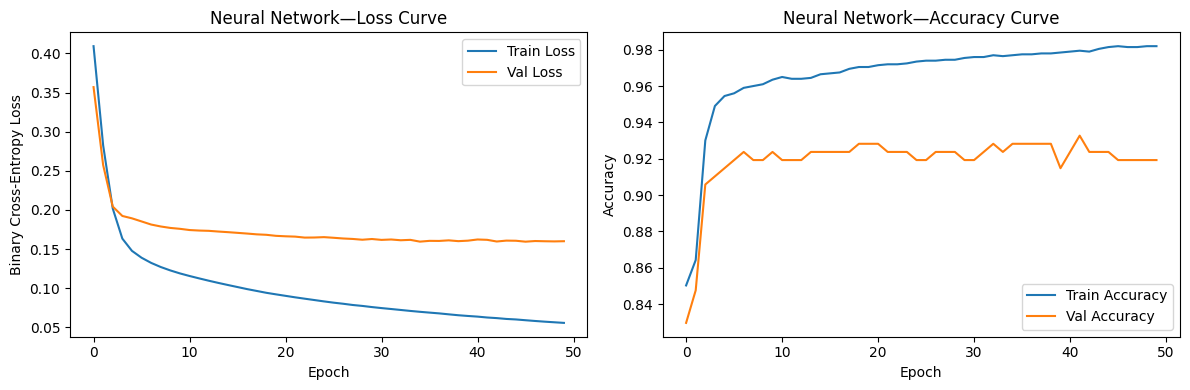

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Neural Network Test Accuracy: 96.41 %

Classification Report:
              precision    recall  f1-score   support

 Non-Sterile       0.98      0.98      0.98       472
     Sterile       0.89      0.87      0.88        85

    accuracy                           0.96       557
   macro avg       0.93      0.93      0.93       557
weighted avg       0.96      0.96      0.96       557



In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Neural Network—Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Neural Network—Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

y_pred_nn_prob = nn_model.predict(X_test_s).flatten()
y_pred_nn = (y_pred_nn_prob >= 0.5).astype(int)

print('Neural Network Test Accuracy:', round(accuracy_score(y_test, y_pred_nn)*100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nn, target_names=['Non-Sterile', 'Sterile']))

### 5.6 KMeans Clustering (Unsupervised)

KMeans — Cluster sizes (test set):
  Cluster 0: 299 samples
  Cluster 1: 258 samples


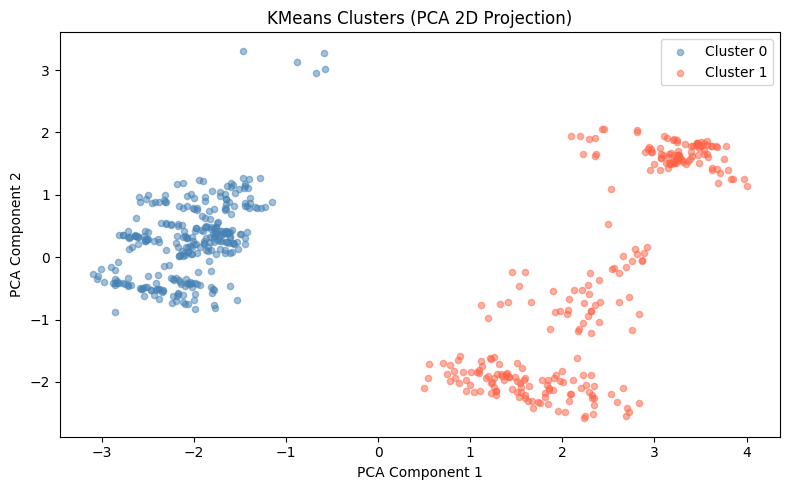

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_s)
cluster_labels = kmeans.predict(X_test_s)

print('KMeans — Cluster sizes (test set):')
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} samples')

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test_s)

plt.figure(figsize=(8, 5))
for cluster_id, color in zip([0, 1], ['steelblue', 'tomato']):
    mask = cluster_labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=f'Cluster {cluster_id}', alpha=0.5, s=20)
plt.title('KMeans Clusters (PCA 2D Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

---
## 6. Model Selection / Comparison Analysis

In [ ]:
all_models = {
    'KNN':                 (y_pred_knn, knn.predict_proba(X_test_s)[:,1]),
    'Logistic Regression': (y_pred_lr,  lr.predict_proba(X_test_s)[:,1]),
    'Naive Bayes':         (y_pred_nb,  nb.predict_proba(X_test_s)[:,1]),
    'Neural Network':      (y_pred_nn,  y_pred_nn_prob),
}

### 6.1 Accuracy Comparison

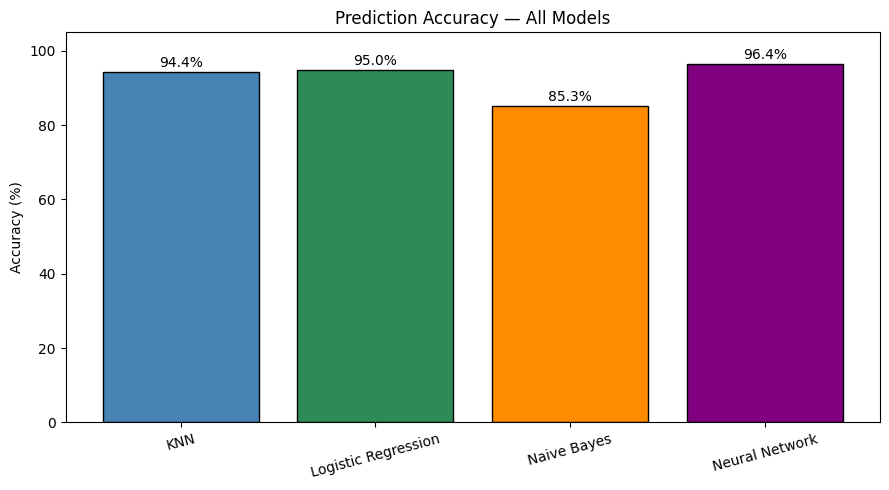

Accuracy Summary:
  KNN: 94.43%
  Logistic Regression: 94.97%
  Naive Bayes: 85.28%
  Neural Network: 96.41%


In [ ]:
accuracies = {name: accuracy_score(y_test, preds) for name, (preds, _) in all_models.items()}

plt.figure(figsize=(9, 5))
bars = plt.bar(accuracies.keys(), [v*100 for v in accuracies.values()],
               color=['steelblue','seagreen','darkorange','purple','crimson'],
               edgecolor='black')
plt.title('Prediction Accuracy — All Models')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.xticks(rotation=15)
for bar, val in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print('Accuracy Summary:')
for name, acc in accuracies.items():
    print(f'  {name}: {acc*100:.2f}%')

### 6.2 Precision & Recall Comparison

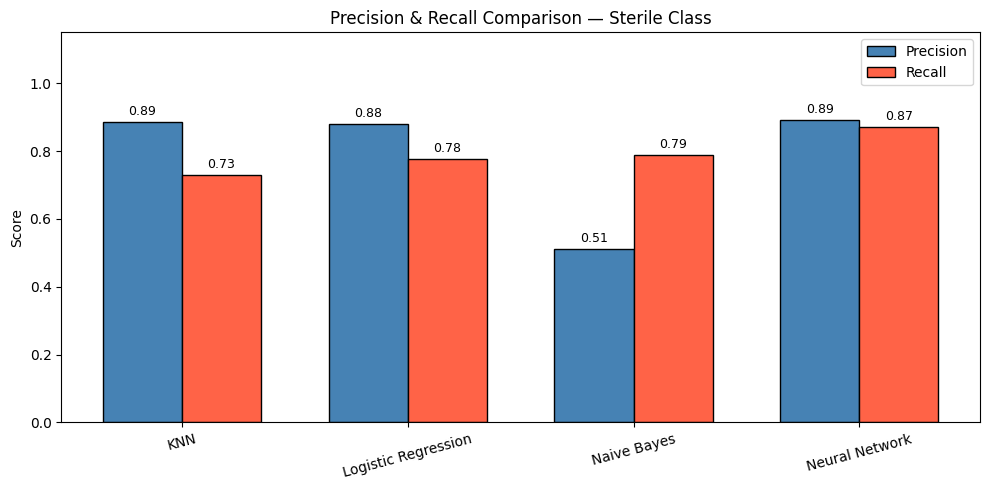

Precision & Recall (Sterile class):
  KNN: Precision=0.8857, Recall=0.7294
  Logistic Regression: Precision=0.8800, Recall=0.7765
  Naive Bayes: Precision=0.5115, Recall=0.7882
  Neural Network: Precision=0.8916, Recall=0.8706


In [ ]:
model_names = list(all_models.keys())
precisions = [precision_score(y_test, preds, zero_division=0) for preds, _ in all_models.values()]
recalls    = [recall_score(y_test, preds, zero_division=0)    for preds, _ in all_models.values()]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, precisions, width, label='Precision', color='steelblue', edgecolor='black')
plt.bar(x + width/2, recalls,    width, label='Recall',    color='tomato',    edgecolor='black')
plt.title('Precision & Recall Comparison — Sterile Class')
plt.xticks(x, model_names, rotation=15)
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.legend()
for i, (p, r) in enumerate(zip(precisions, recalls)):
    plt.text(i - width/2, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)
    plt.text(i + width/2, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Precision & Recall (Sterile class):')
for name, p, r in zip(model_names, precisions, recalls):
    print(f'  {name}: Precision={p:.4f}, Recall={r:.4f}')

### 6.3 Confusion Matrices

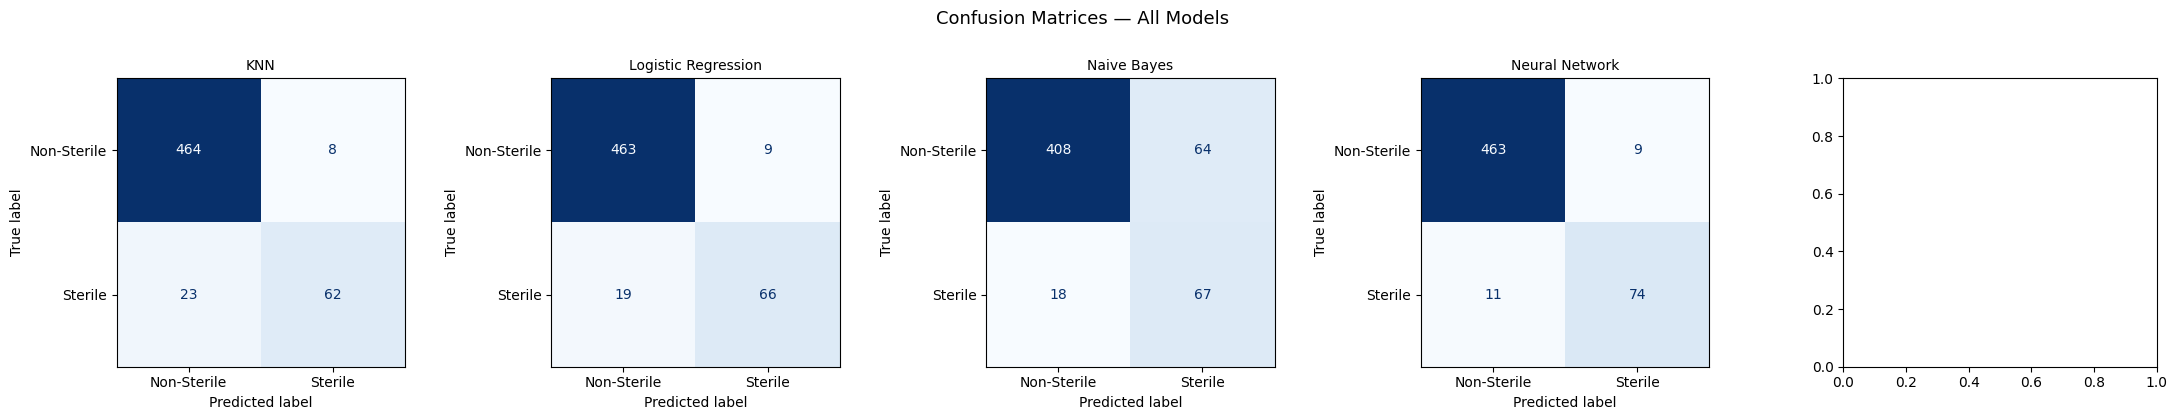

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, (preds, _)) in zip(axes, all_models.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Sterile','Sterile'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10)
plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.4 ROC Curves & AUC Scores

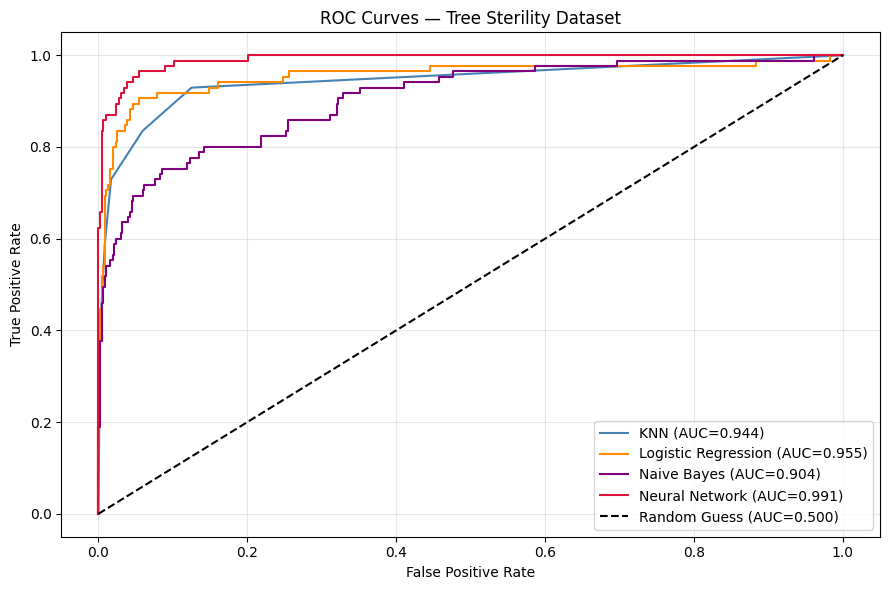

AUC Scores:
  KNN: AUC = 0.9444
  Logistic Regression: AUC = 0.9548
  Naive Bayes: AUC = 0.9040
  Neural Network: AUC = 0.9910


In [ ]:
plt.figure(figsize=(9, 6))
colors_roc = ['steelblue','darkorange','purple','crimson']

for (name, (_, probs)), color in zip(all_models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color)

plt.plot([0,1],[0,1],'k--', label='Random Guess (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tree Sterility Dataset')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('AUC Scores:')
for name, (_, probs) in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    print(f'  {name}: AUC = {auc(fpr, tpr):.4f}')